# Netflix Dataset — Exploratory Data Analysis

---

> **Author:** Anshika Mittal (1AUA23BIT005)  
> **Dataset:** Netflix Titles (netflix_titles.csv)  
> **Tools:** Python · Pandas · Matplotlib · Seaborn · Plotly  
> **Goal:** Uncover content trends, distribution patterns, and strategic insights from Netflix's global catalog.

---

## Table of Contents
1. [Import Libraries](#1)
2. [Load Dataset](#2)
3. [Data Understanding](#3)
4. [Data Cleaning](#4)
5. [Feature Engineering](#5)
6. [Exploratory Data Analysis](#6)
7. [Advanced Visualizations](#7)
8. [Insights & Conclusion](#8)

---
## 1.  Import Libraries <a id='1'></a>

In [7]:
!pip install -U plotly

In [1]:
!pip uninstall -y kaleido
!pip install kaleido==0.2.1

Found existing installation: kaleido 0.2.1
Uninstalling kaleido-0.2.1:
  Successfully uninstalled kaleido-0.2.1
  Using cached kaleido-0.2.1-py2.py3-none-manylinux1_x86_64.whl.metadata (15 kB)
Using cached kaleido-0.2.1-py2.py3-none-manylinux1_x86_64.whl (79.9 MB)


In [2]:
import plotly.io as pio
pio.kaleido.scope.default_format = "png"

/tmp/ipykernel_15519/3688147373.py:2: DeprecationWarning: 
Use of plotly.io.kaleido.scope.default_format is deprecated and support will be removed after September 2025.
Please use plotly.io.defaults.default_format instead.

  pio.kaleido.scope.default_format = "png"


In [3]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [4]:
# ─── Standard Library ────────────────────────────────────────────────────────
import os
import warnings
from datetime import datetime

# ─── Data Manipulation ───────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ─── Static Visualizations ───────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ─── Interactive Visualizations ──────────────────────────────────────────────
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ─── Settings ────────────────────────────────────────────────────────────────
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 60)

# ─── Matplotlib Global Style ─────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 15,
    'axes.labelsize': 12,
})
NETFLIX_RED   = '#E50914'
NETFLIX_BLACK = '#141414'
PALETTE       = ['#E50914', '#B20710', '#F5A623', '#221F1F', '#564D4D',
                 '#A8A8A8', '#D63031', '#FF7675', '#FDCB6E', '#6C5CE7']

# ─── Output Folder ───────────────────────────────────────────────────────────
os.makedirs('charts', exist_ok=True)
print('All libraries imported. charts/ folder ready.')

All libraries imported. charts/ folder ready.


---
## 2. Load Dataset <a id='2'></a>

The dataset is loaded from the local path. If you're running this on **Google Colab**, upload the CSV first via the Files panel or mount Google Drive, then update `DATA_PATH` accordingly.

In [5]:
DATA_PATH = r"C:\Users\anshi\Desktop\COURSES\PROJECTS\Data_Visualization\Netflix_Dashboard\data\netflix_titles.csv"

# ── For Colab: uncomment and upload ──────────────────────────────────────────
from google.colab import files
uploaded = files.upload()          # upload netflix_titles.csv
DATA_PATH = 'netflix_titles.csv'

df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()   # keep original untouched

print(f'Shape  : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Memory : {df.memory_usage(deep=True).sum() / 1024:.1f} KB')
df.head(3)

Saving netflix_titles.csv to netflix_titles (5).csv
Shape  : 8,807 rows × 12 columns
Memory : 7980.2 KB


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmmaker Kirst..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thabang Molaba, ...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town teen sets o..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabiha Akkari,...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Action & Adve...","To protect his family from a powerful drug lord, skilled..."


---
## 3. Data Understanding <a id='3'></a>

Before cleaning, we must understand the **shape**, **types**, **missing values**, and **cardinality** of every column.

In [6]:
print('=' * 55)
print(' COLUMN INFO')
print('=' * 55)
df.info()

 COLUMN INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [8]:
print('\n── Missing Values ───────────────────────────────────────')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(missing_df.to_string())


── Missing Values ───────────────────────────────────────
            Missing Count  Missing %
director             2634      29.91
country               831       9.44
cast                  825       9.37
date_added             10       0.11
rating                  4       0.05
duration                3       0.03


In [12]:
print('\n── Unique Values per Column ─────────────────────────────')
for col in df.columns:
    print(f'  {col:<20}: {df[col].nunique():>5} unique')


── Unique Values per Column ─────────────────────────────
  show_id             :  8807 unique
  type                :     2 unique
  title               :  8807 unique
  director            :  4528 unique
  cast                :  7692 unique
  country             :   748 unique
  date_added          :  1767 unique
  release_year        :    74 unique
  rating              :    17 unique
  duration            :   220 unique
  listed_in           :   514 unique
  description         :  8775 unique


In [13]:
print('\n── Basic Statistics ─────────────────────────────────────')
df.describe(include='all').T


── Basic Statistics ─────────────────────────────────────


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
show_id,8807,8807,s8807,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,8807,2,Movie,6131,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,8807,8807,Zubaan,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
director,6173,4528,Rajiv Chilaka,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cast,7982,7692,David Attenborough,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,7976,748,United States,2818,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_added,8797,1767,"January 1, 2020",109,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_year,8807.0,NaN,NaN,NaN,2014.180198,8.819312,1925.0,2013.0,2017.0,2019.0,2021.0
rating,8803,17,TV-MA,3207,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,8804,220,1 Season,1793,NaN,NaN,NaN,NaN,NaN,NaN,NaN


###  Key Observations
- **`director`** and **`cast`** have the most missing data (~30% and ~9% respectively) — expected for documentaries/specials.
- **`country`**, **`date_added`**, and **`rating`** have smaller but non-trivial gaps.
- **`duration`** mixes units (`min` for movies, `Season(s)` for shows) — needs splitting.
- **`listed_in`** contains comma-separated multi-genre tags — primary genre extraction will help.

---
## 4. Data Cleaning <a id='4'></a>

In [14]:
# ── 4.1  Remove Duplicates ───────────────────────────────────────────────────
before = len(df)
df.drop_duplicates(subset='show_id', inplace=True)
print(f'Duplicates removed : {before - len(df)} rows  →  {len(df):,} rows remain')

Duplicates removed : 0 rows  →  8,807 rows remain


In [15]:
# ── 4.2  Handle Missing Values ───────────────────────────────────────────────

# High-missingness text cols: fill with 'Unknown'
for col in ['director', 'cast', 'country']:
    df[col].fillna('Unknown', inplace=True)

# Rating: fill with mode (most common rating)
df['rating'].fillna(df['rating'].mode()[0], inplace=True)

# date_added: drop rows where it's missing (tiny %, breaks datetime logic)
df.dropna(subset=['date_added'], inplace=True)

# duration: fill with 'Unknown'
df['duration'].fillna('Unknown', inplace=True)

print('Missing values after cleaning:')
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values after cleaning:
Series([], dtype: int64)


In [16]:
# ── 4.3  Parse date_added → datetime, extract year & month ──────────────────
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), format='%B %d, %Y', errors='coerce')
df.dropna(subset=['date_added'], inplace=True)   # drop unparseable dates

df['year_added']  = df['date_added'].dt.year.astype(int)
df['month_added'] = df['date_added'].dt.month.astype(int)
df['month_name']  = df['date_added'].dt.strftime('%b')  # Jan, Feb …

print('Date range:', df['date_added'].min().date(), '→', df['date_added'].max().date())
df[['date_added', 'year_added', 'month_added', 'month_name']].head(3)

Date range: 2008-01-01 → 2021-09-25


,date_added,year_added,month_added,month_name
0,2021-09-25,2021,9,Sep
1,2021-09-24,2021,9,Sep
2,2021-09-24,2021,9,Sep


In [17]:
# ── 4.4  Clean duration column ───────────────────────────────────────────────
# Split '90 min' → 90 (numeric) + 'min' (unit)

def parse_duration(val):
    if pd.isna(val) or val == 'Unknown':
        return None, None
    parts = str(val).split()
    try:
        return int(parts[0]), ' '.join(parts[1:])
    except (ValueError, IndexError):
        return None, None

df['duration_value'], df['duration_unit'] = zip(*df['duration'].map(parse_duration))
df['duration_value'] = pd.to_numeric(df['duration_value'], errors='coerce')

print('Duration value range:')
print(df.groupby('duration_unit')['duration_value'].describe().round(1))

Duration value range:
                count  mean   std  min   25%   50%    75%    max
duration_unit                                                   
Season         1793.0   1.0   0.0  1.0   1.0   1.0    1.0    1.0
Seasons         873.0   3.3   1.9  2.0   2.0   3.0    4.0   17.0
min            6128.0  99.6  28.3  3.0  87.0  98.0  114.0  312.0


### Cleaning Summary
- Zero duplicate `show_id` entries were found — the raw dataset is already fairly clean.
- `director` / `cast` gaps are genuine (many titles have no named director on record).
- Movies average **~100 min**; TV Shows average **~1–2 seasons** — very different distributions, so they must always be analyzed separately.

---
## 5.  Feature Engineering <a id='5'></a>

In [18]:
CURRENT_YEAR = datetime.now().year

# ── 5.1  Content Age ─────────────────────────────────────────────────────────
df['content_age'] = CURRENT_YEAR - df['release_year']

# ── 5.2  Decade of Release ───────────────────────────────────────────────────
df['decade'] = (df['release_year'] // 10 * 10).astype(str) + 's'

# ── 5.3  Primary Genre (first tag in listed_in) ──────────────────────────────
df['primary_genre'] = df['listed_in'].str.split(',').str[0].str.strip()

# ── 5.4  Primary Country (first in comma-separated list) ─────────────────────
df['primary_country'] = df['country'].str.split(',').str[0].str.strip()
df.loc[df['primary_country'] == 'Unknown', 'primary_country'] = 'Unknown'

# ── 5.5  Is Recent? (added in last 3 years of data) ──────────────────────────
cutoff = df['year_added'].max() - 2
df['is_recent'] = df['year_added'] >= cutoff

# ── 5.6  Season bucket (TV Shows only) ───────────────────────────────────────
def season_bucket(row):
    if row['type'] != 'TV Show' or pd.isna(row['duration_value']):
        return None
    v = row['duration_value']
    if v == 1:   return '1 Season'
    elif v <= 3: return '2–3 Seasons'
    elif v <= 6: return '4–6 Seasons'
    else:        return '7+ Seasons'

df['season_bucket'] = df.apply(season_bucket, axis=1)

print('New features created:')
new_cols = ['content_age', 'decade', 'primary_genre', 'primary_country', 'is_recent', 'season_bucket']
df[new_cols].head(5)

New features created:


,content_age,decade,primary_genre,primary_country,is_recent,season_bucket
0,6,2020s,Documentaries,United States,True,None
1,5,2020s,International TV Shows,South Africa,True,2–3 Seasons
2,5,2020s,Crime TV Shows,Unknown,True,1 Season
3,5,2020s,Docuseries,Unknown,True,1 Season
4,5,2020s,International TV Shows,India,True,2–3 Seasons


### Feature Engineering Notes
- **`content_age`** lets us ask: *Is Netflix's library fresh or archival?*
- **`decade`** reveals which eras dominate the catalog.
- **`primary_genre`** reduces multi-tag noise for genre charts.
- **`season_bucket`** shows whether Netflix bets on short or long-form TV shows.

---
## 6. Exploratory Data Analysis <a id='6'></a>

### 6.1 Movies vs TV Shows

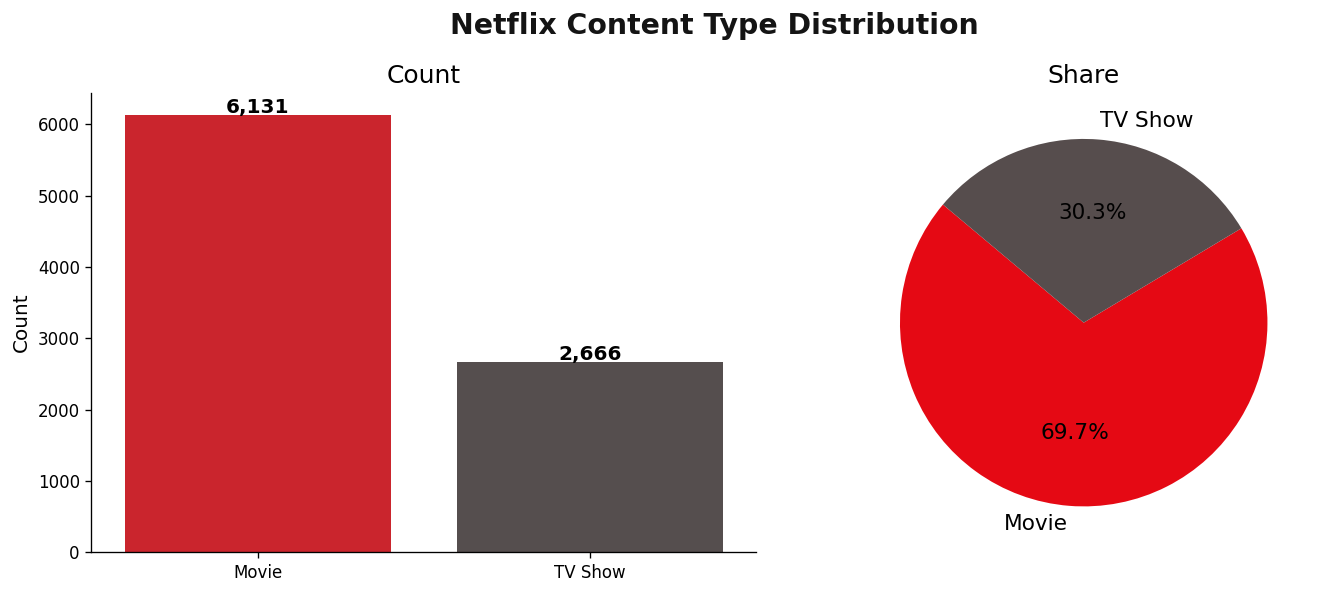

Saved: charts/movies_vs_tv.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
from google.colab import files
type_counts = df['type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Netflix Content Type Distribution', fontsize=17, fontweight='bold', color=NETFLIX_BLACK)

# Countplot
sns.countplot(data=df, x='type', palette=[NETFLIX_RED, '#564D4D'],
              order=type_counts.index, ax=axes[0])
axes[0].set_title('Count')
axes[0].set_xlabel(''); axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width() / 2, p.get_height() + 30),
                     ha='center', fontsize=12, fontweight='bold')

# Pie chart
axes[1].pie(type_counts, labels=type_counts.index, autopct='%1.1f%%',
            colors=[NETFLIX_RED, '#564D4D'], startangle=140,
            textprops={'fontsize': 13})
axes[1].set_title('Share')

plt.tight_layout()
plt.savefig('charts/movies_vs_tv.png', bbox_inches='tight')
plt.show()
print('Saved: charts/movies_vs_tv.png')
files.download('charts/movies_vs_tv.png')

**Insight:** Movies outnumber TV Shows by roughly **2:1**, confirming Netflix's strong focus on film content — though TV Shows drive the majority of watch-time via binge culture.

### 6.2 Ratings Distribution

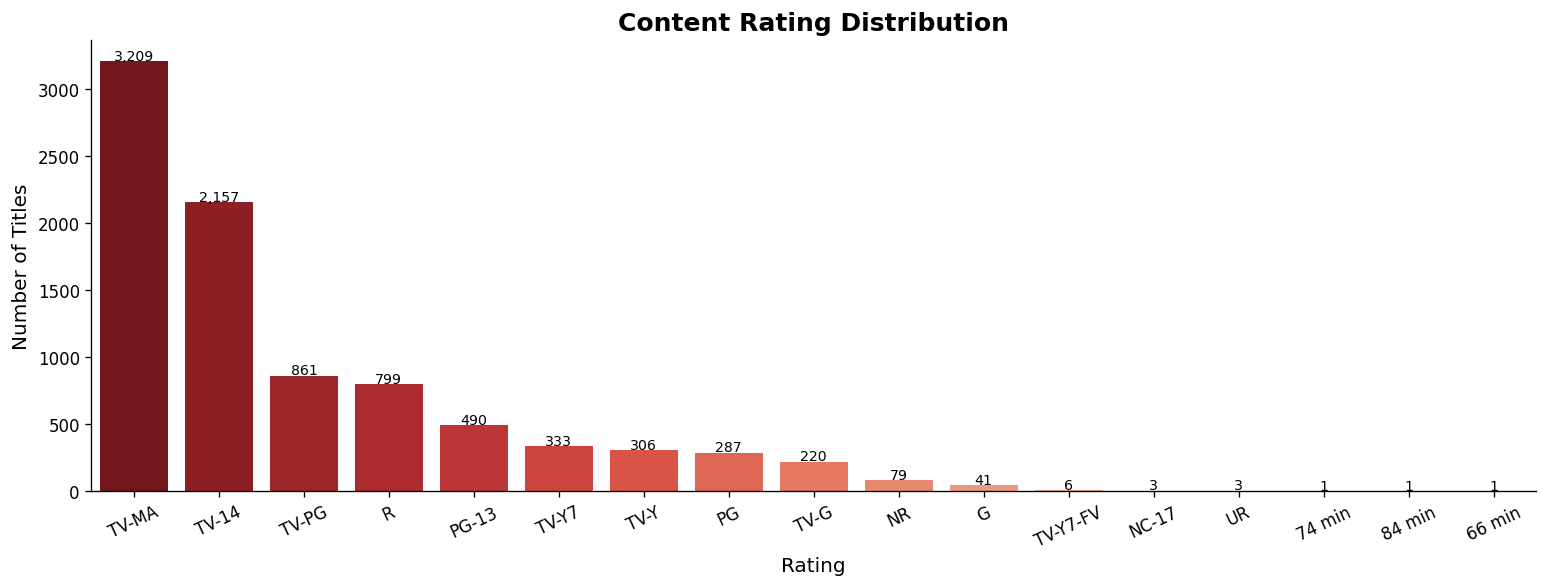

Saved: charts/ratings_distribution.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
from google.colab import files
rating_order = df['rating'].value_counts().index

fig, ax = plt.subplots(figsize=(13, 5))
sns.countplot(data=df, x='rating', order=rating_order,
              palette=sns.color_palette('Reds_r', len(rating_order)), ax=ax)
ax.set_title('Content Rating Distribution', fontsize=15, fontweight='bold')
ax.set_xlabel('Rating'); ax.set_ylabel('Number of Titles')
ax.tick_params(axis='x', rotation=25)
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height()):,}',
                    (p.get_x() + p.get_width() / 2, p.get_height() + 10),
                    ha='center', fontsize=8.5)
plt.tight_layout()
plt.savefig('charts/ratings_distribution.png', bbox_inches='tight')
plt.show()
print('Saved: charts/ratings_distribution.png')
files.download('charts/ratings_distribution.png')

** Insight:** **TV-MA** dominates — Netflix heavily targets **mature adult audiences**, not families. **TV-14** and **TV-PG** are a distant second tier, while children's ratings (G, TV-Y) are marginal.

### 6.3 Content Added Per Year

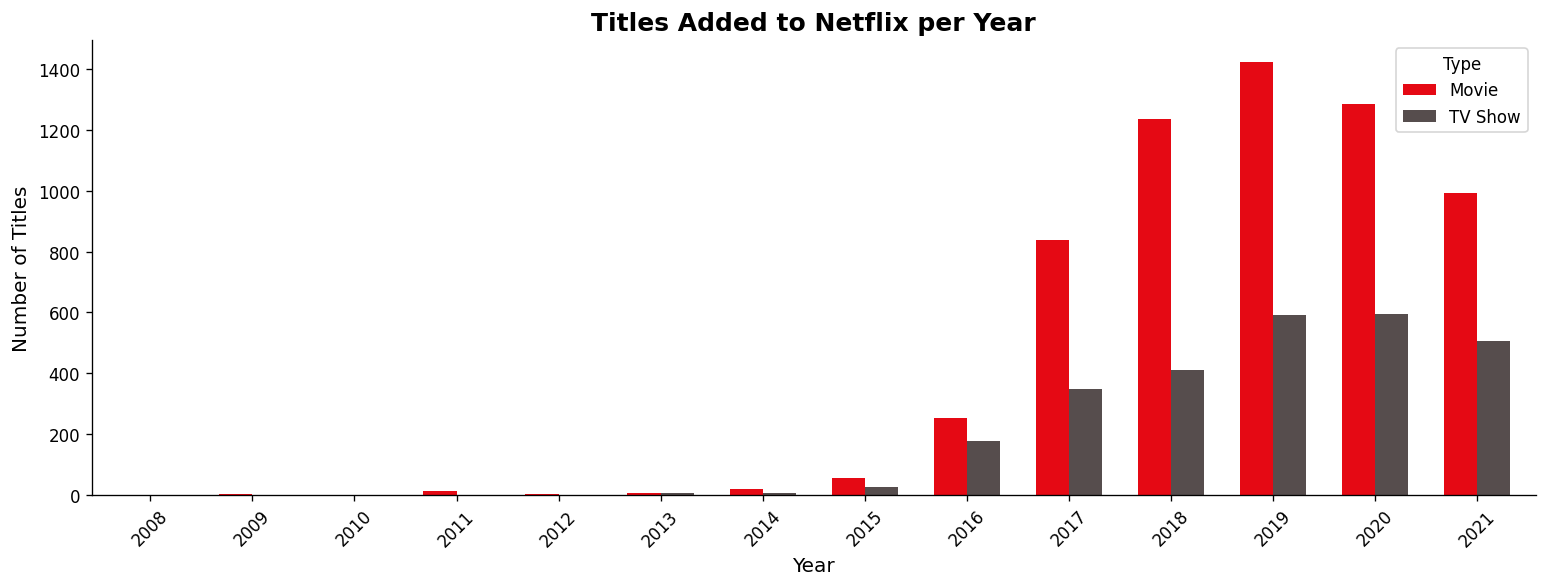

Saved: charts/content_added_per_year.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
from google.colab import files
yearly = df.groupby(['year_added', 'type']).size().unstack(fill_value=0).reset_index()

fig, ax = plt.subplots(figsize=(13, 5))
yearly.set_index('year_added')[['Movie', 'TV Show']].plot(
    kind='bar', stacked=False, color=[NETFLIX_RED, '#564D4D'],
    width=0.65, ax=ax
)
ax.set_title('Titles Added to Netflix per Year', fontsize=15, fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Number of Titles')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Type')
plt.tight_layout()
plt.savefig('charts/content_added_per_year.png', bbox_inches='tight')
plt.show()
print('Saved: charts/content_added_per_year.png')
files.download('charts/content_added_per_year.png')

** Insight:** Netflix's aggressive expansion peaking around **2018–2020** mirrors its international push and original-content investment era. Post-2020 additions appear lower — likely reflecting the dataset's recency cutoff.

### 6.4 Top 10 Countries

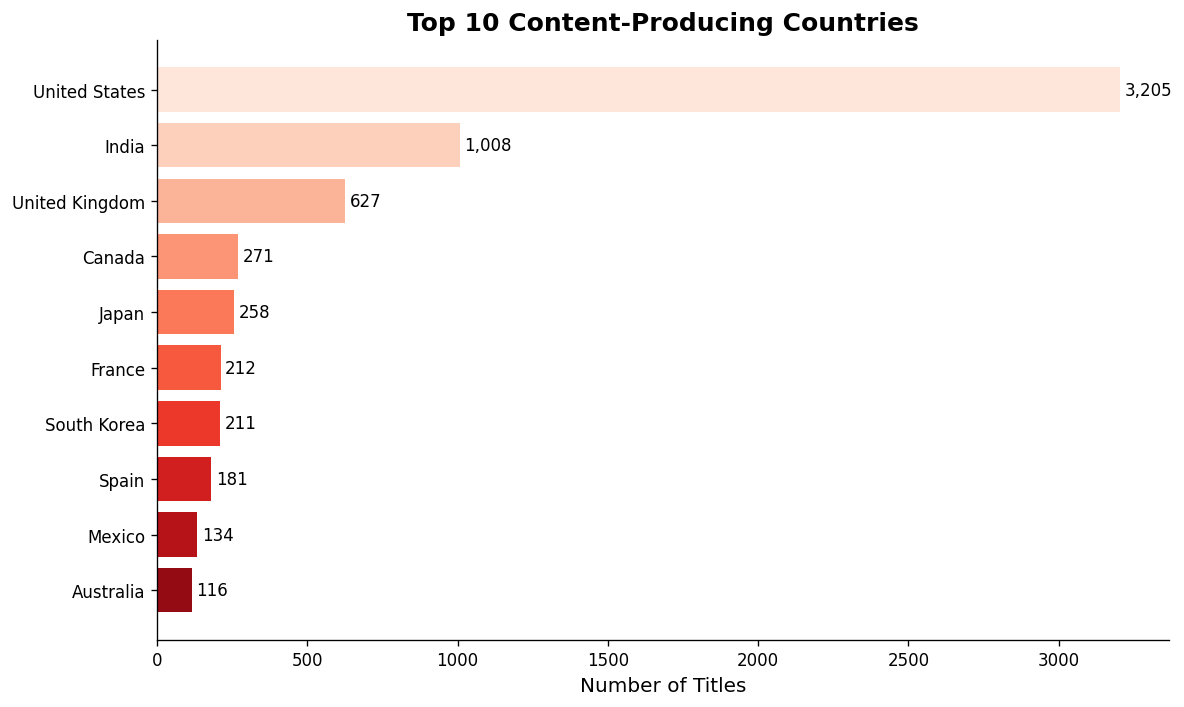

Saved: charts/top_countries.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
from google.colab import files
top_countries = (
    df[df['primary_country'] != 'Unknown']
    ['primary_country'].value_counts().head(10)
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_countries.index[::-1], top_countries.values[::-1],
               color=sns.color_palette('Reds_r', 10))
ax.set_title('Top 10 Content-Producing Countries', fontsize=15, fontweight='bold')
ax.set_xlabel('Number of Titles')
for bar, val in zip(bars, top_countries.values[::-1]):
    ax.text(bar.get_width() + 15, bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('charts/top_countries.png', bbox_inches='tight')
plt.show()
print('Saved: charts/top_countries.png')
files.download('charts/top_countries.png')

** Insight:** **United States** is the dominant content producer by a wide margin. **India** ranks 2nd — reflecting Bollywood's scale and Netflix's aggressive South Asian investment. **UK, Canada, France** round out the Western cluster.

### 6.5 Top 15 Genres

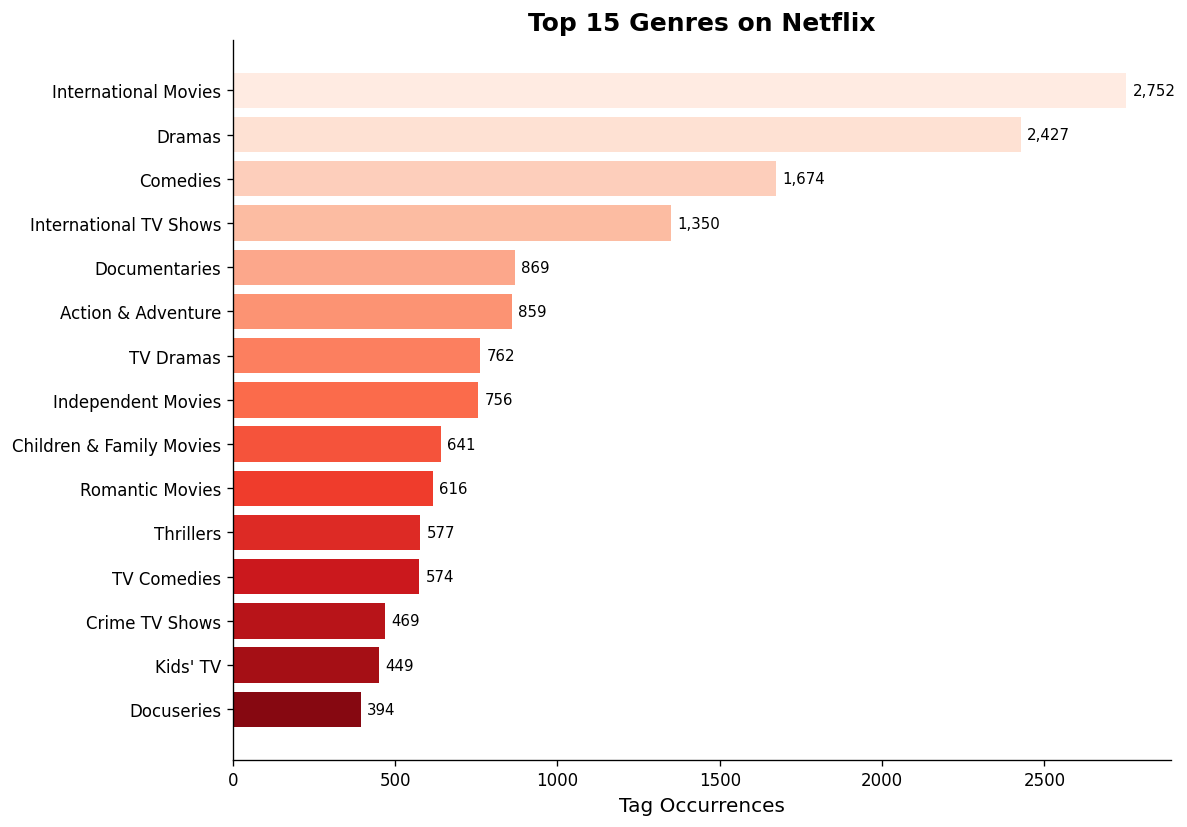

Saved: charts/top_genres.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
from google.colab import files
# Explode multi-genre tags for a full count
all_genres = df['listed_in'].str.split(', ').explode().str.strip()
top_genres = all_genres.value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 7))
colors = sns.color_palette('Reds_r', 15)
bars = ax.barh(top_genres.index[::-1], top_genres.values[::-1], color=colors)
ax.set_title('Top 15 Genres on Netflix', fontsize=15, fontweight='bold')
ax.set_xlabel('Tag Occurrences')
for bar, val in zip(bars, top_genres.values[::-1]):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('charts/top_genres.png', bbox_inches='tight')
plt.show()
print('Saved: charts/top_genres.png')
files.download('charts/top_genres.png')

**Insight:** **International Movies, Dramas, and Comedies** are Netflix's bread-and-butter genres. The prominence of `International` tags signals that a huge share of the catalog targets non-US subscribers.


### 6.6 Monthly Content Addition Trend

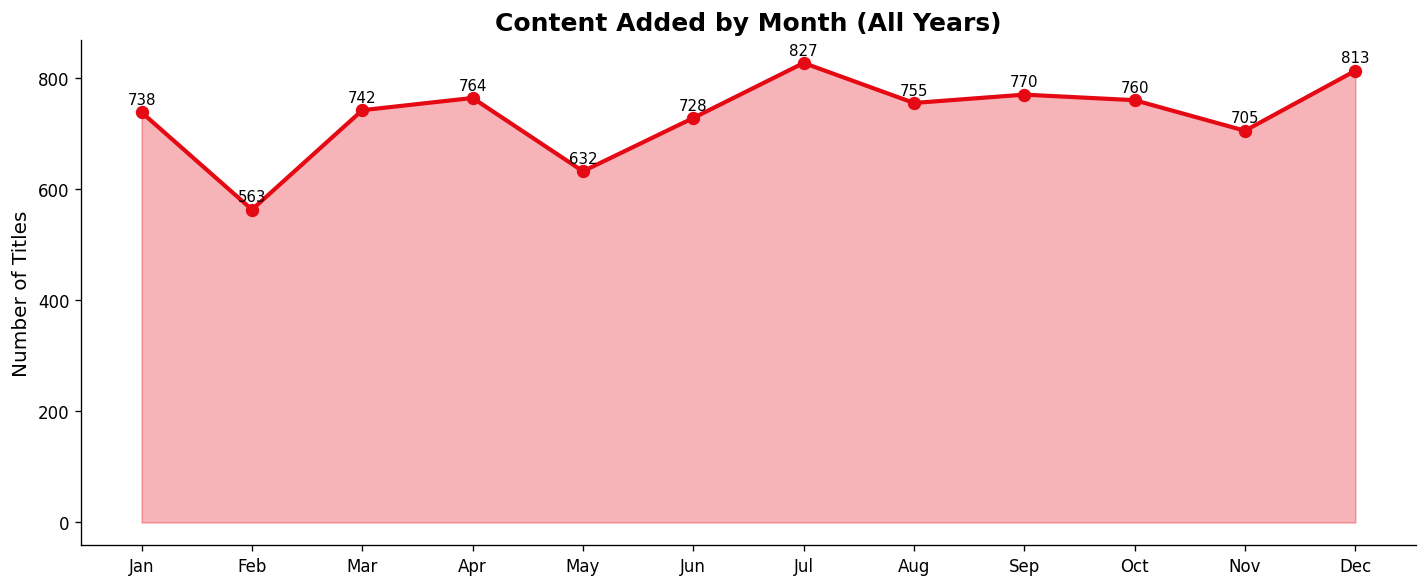

Saved: charts/monthly_addition_trend.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
from google.colab import files
month_order = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
monthly = df['month_name'].value_counts().reindex(month_order)

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(range(len(monthly)), monthly.values, alpha=0.3, color=NETFLIX_RED)
ax.plot(range(len(monthly)), monthly.values, color=NETFLIX_RED,
        marker='o', linewidth=2.5, markersize=7)
ax.set_xticks(range(12))
ax.set_xticklabels(month_order)
ax.set_title('Content Added by Month (All Years)', fontsize=15, fontweight='bold')
ax.set_ylabel('Number of Titles')
for i, v in enumerate(monthly.values):
    ax.annotate(str(v), (i, v + 15), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('charts/monthly_addition_trend.png', bbox_inches='tight')
plt.show()
print('Saved: charts/monthly_addition_trend.png')
files.download('charts/monthly_addition_trend.png')

** Insight:** **July** and **December** see the sharpest spikes — Netflix times major releases around summer holidays and the holiday season to maximise subscriber engagement.

---
## 7. Advanced Visualizations <a id='7'></a>

### 7.1 Heatmap — Year × Month Content Addition

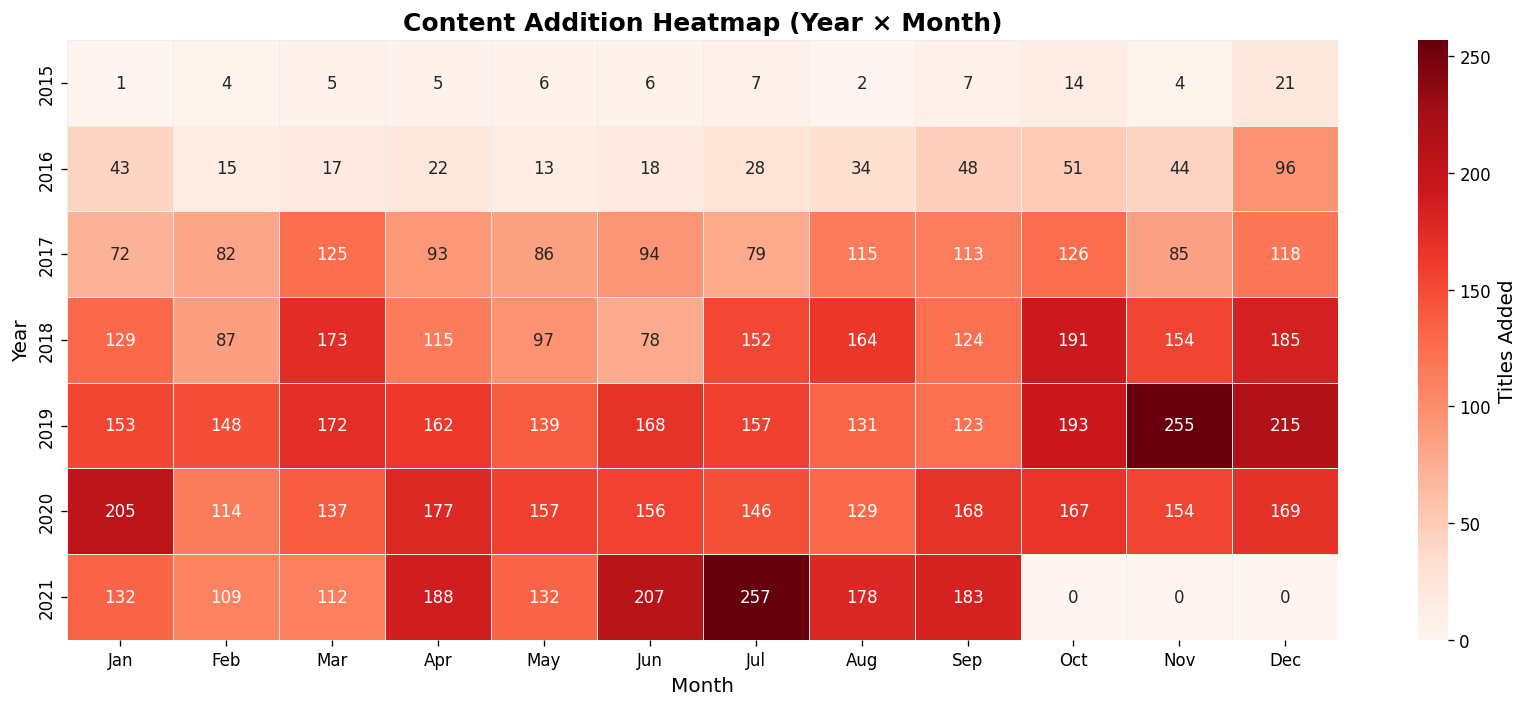

Saved: charts/heatmap_year_month.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
from google.colab import files
month_order = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

pivot = (
    df.groupby(['year_added', 'month_name'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=month_order, fill_value=0)
)
pivot = pivot[pivot.index >= 2015]  # focus on streaming era

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pivot, cmap='Reds', annot=True, fmt='d',
            linewidths=0.4, linecolor='#eee',
            cbar_kws={'label': 'Titles Added'}, ax=ax)
ax.set_title('Content Addition Heatmap (Year × Month)', fontsize=15, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Year')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('charts/heatmap_year_month.png', bbox_inches='tight')
plt.show()
print('Saved: charts/heatmap_year_month.png')
files.download('charts/heatmap_year_month.png')

**Insight:** The **2019–2020** band is the deepest red across almost every month — this was Netflix's peak content-acquisition period before COVID disrupted production pipelines. **Q4 months** (Oct–Dec) consistently run hotter than Q1.

### 7.2 Duration Distribution & Boxplot

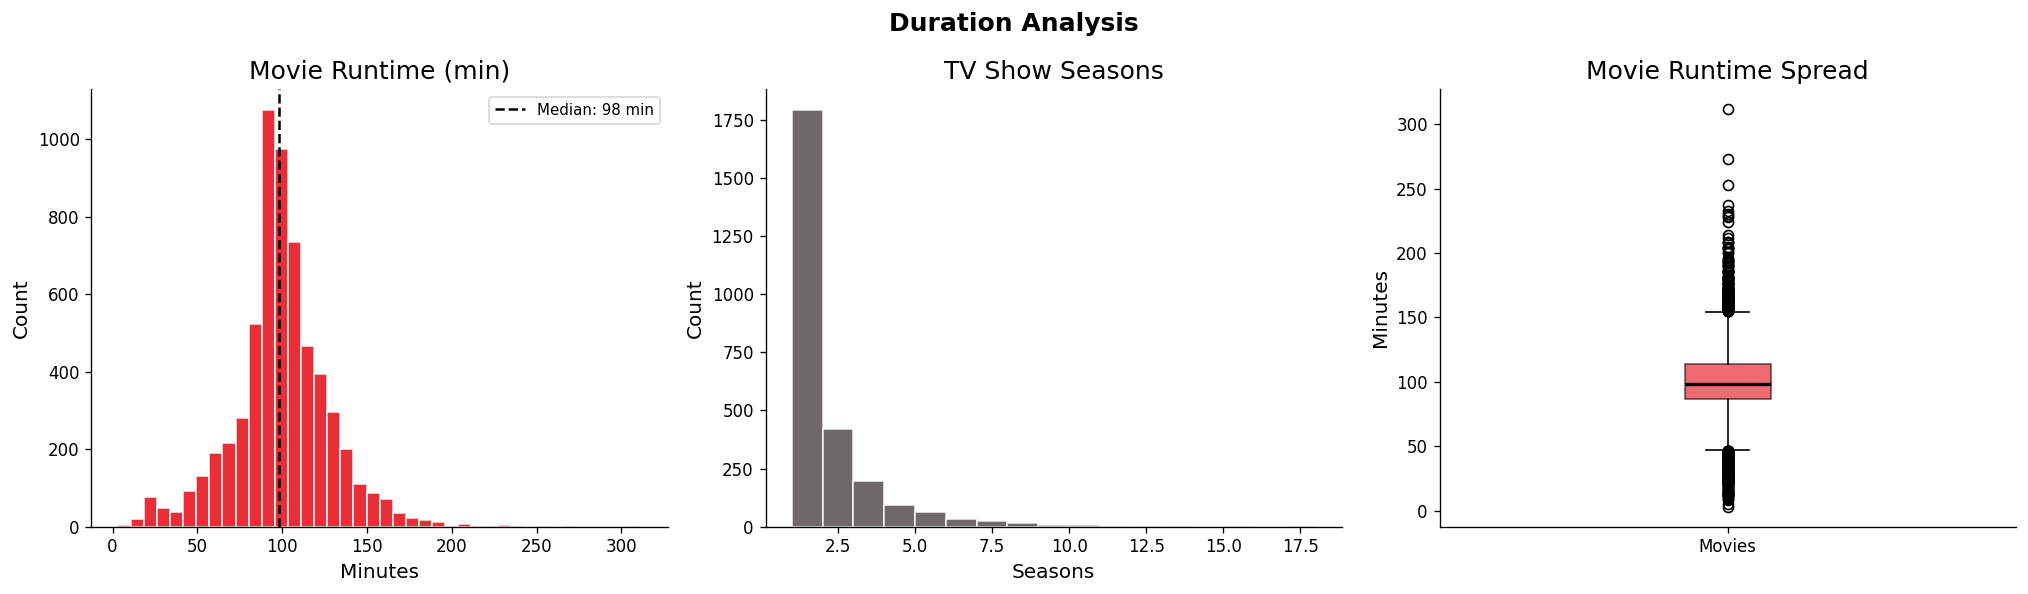

Saved: charts/duration_analysis.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
from google.colab import files
movies = df[(df['type'] == 'Movie') & df['duration_value'].notna()]
shows  = df[(df['type'] == 'TV Show') & df['duration_value'].notna()]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Duration Analysis', fontsize=15, fontweight='bold')

# Movie runtime distribution
axes[0].hist(movies['duration_value'], bins=40, color=NETFLIX_RED,
             edgecolor='white', alpha=0.85)
axes[0].axvline(movies['duration_value'].median(), color='black',
                linestyle='--', label=f'Median: {movies["duration_value"].median():.0f} min')
axes[0].set_title('Movie Runtime (min)')
axes[0].set_xlabel('Minutes'); axes[0].set_ylabel('Count')
axes[0].legend(fontsize=9)

# TV Show seasons distribution
axes[1].hist(shows['duration_value'], bins=range(1, int(shows['duration_value'].max()) + 2),
             color='#564D4D', edgecolor='white', alpha=0.85)
axes[1].set_title('TV Show Seasons')
axes[1].set_xlabel('Seasons'); axes[1].set_ylabel('Count')

# Boxplot: duration by type
box_data = df[df['type'] == 'Movie']['duration_value'].dropna()
axes[2].boxplot(box_data, vert=True, patch_artist=True,
                boxprops=dict(facecolor=NETFLIX_RED, alpha=0.6),
                medianprops=dict(color='black', linewidth=2))
axes[2].set_title('Movie Runtime Spread')
axes[2].set_ylabel('Minutes')
axes[2].set_xticklabels(['Movies'])

plt.tight_layout()
plt.savefig('charts/duration_analysis.png', bbox_inches='tight')
plt.show()
print('Saved: charts/duration_analysis.png')
files.download('charts/duration_analysis.png')

**Insight:** Most Netflix movies cluster between **80–120 minutes** — right in the comfort zone for streaming. The vast majority of TV Shows have just **1 season**, confirming Netflix's preference for limited-run miniseries over long-running franchises.

### 7.3 Stacked Bar — Year vs Content Type

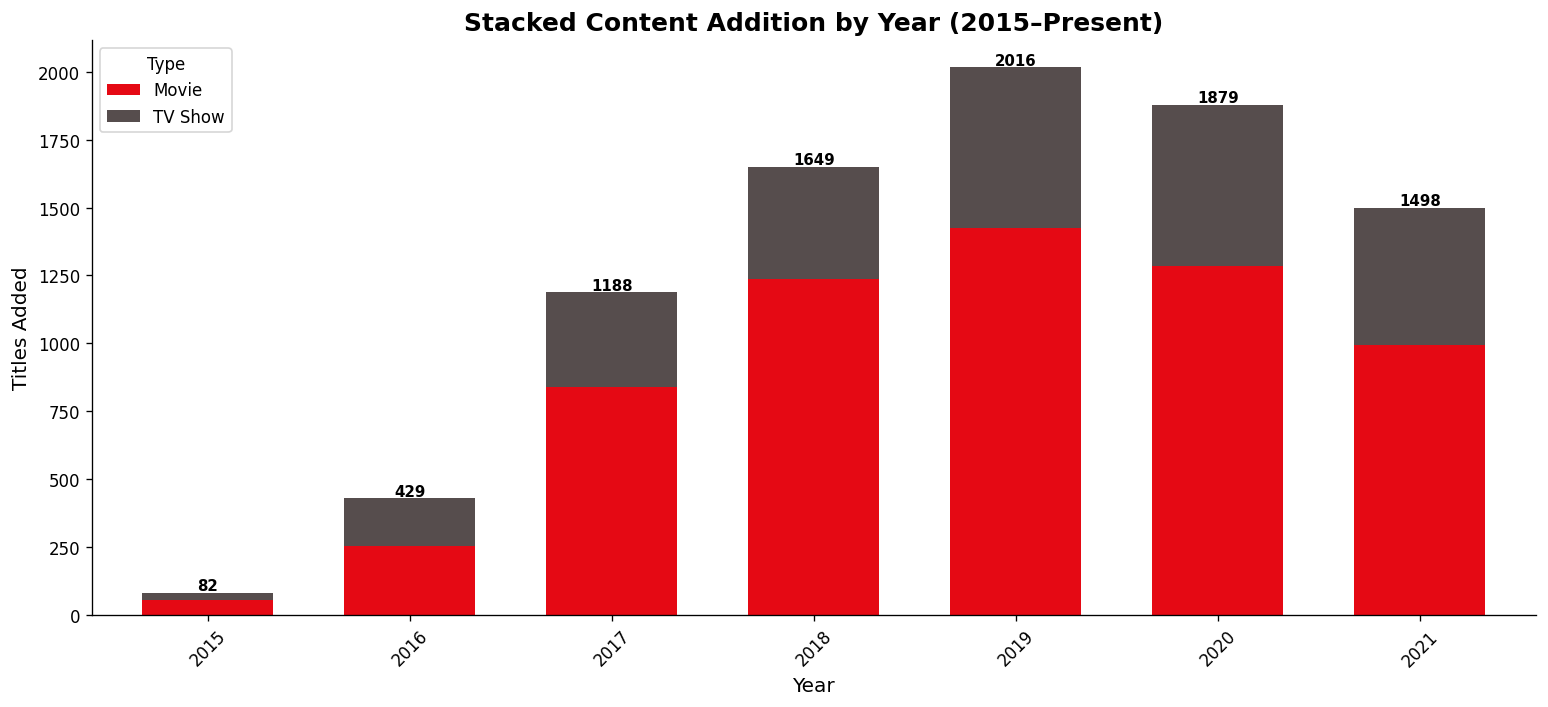

Saved: charts/stacked_year_type.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [27]:
from google.colab import files
stacked = (
    df[df['year_added'] >= 2015]
    .groupby(['year_added', 'type'])
    .size().unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(13, 6))
stacked.plot(kind='bar', stacked=True,
             color=[NETFLIX_RED, '#564D4D'], width=0.65, ax=ax)
ax.set_title('Stacked Content Addition by Year (2015–Present)', fontsize=15, fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Titles Added')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Type', loc='upper left')

# Annotate totals on top
for i, (idx, row) in enumerate(stacked.iterrows()):
    ax.text(i, row.sum() + 10, str(row.sum()), ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('charts/stacked_year_type.png', bbox_inches='tight')
plt.show()
print('Saved: charts/stacked_year_type.png')
files.download('charts/stacked_year_type.png')

**Insight:** While overall additions peaked in **2019**, the **TV Show share has been growing** relative to Movies year-over-year — suggesting Netflix is strategically investing more in episodic originals for retention.

### 7.4 Content Age & Decade Distribution

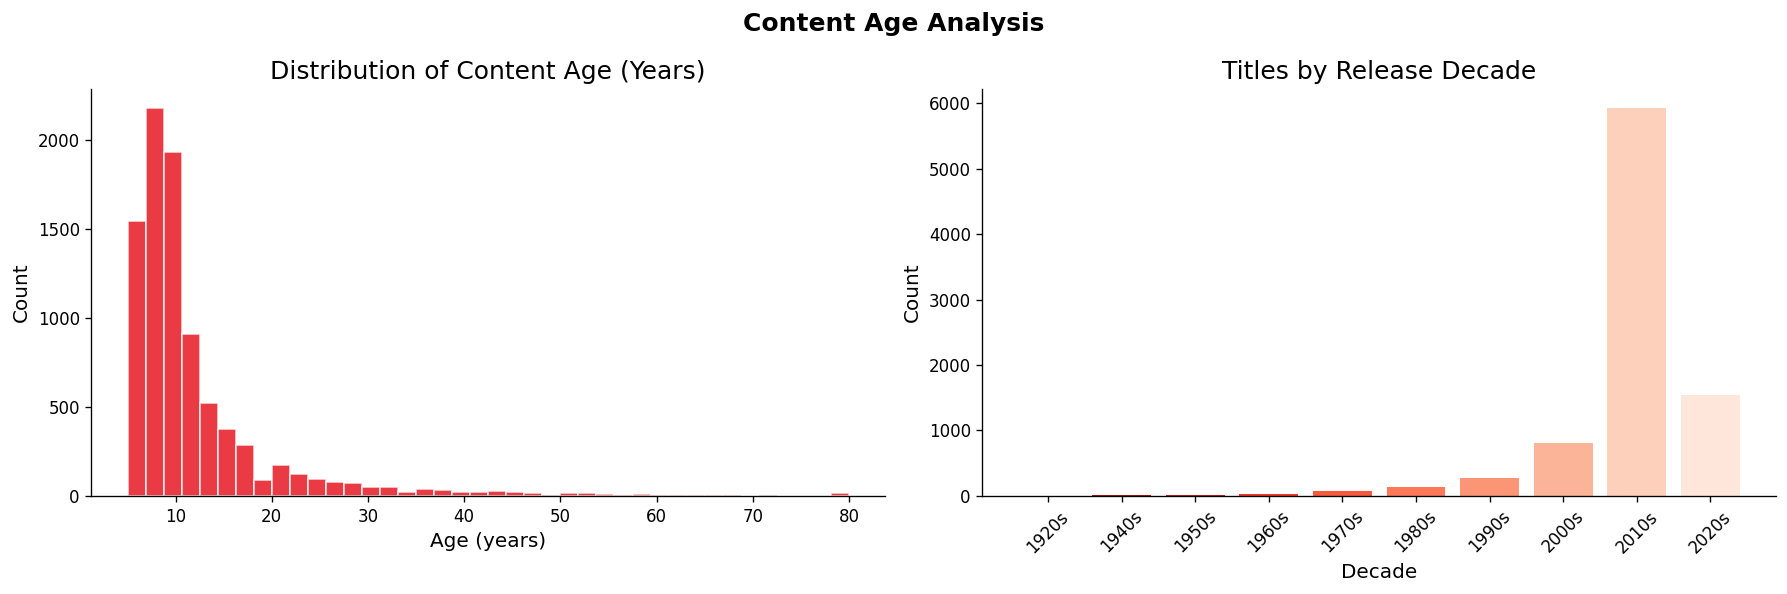

Saved: charts/content_age_decade.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [28]:
from google.colab import files
decade_order = sorted(df['decade'].unique())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Content Age Analysis', fontsize=15, fontweight='bold')

# Content age histogram
axes[0].hist(df['content_age'].clip(0, 80), bins=40,
             color=NETFLIX_RED, edgecolor='white', alpha=0.8)
axes[0].set_title('Distribution of Content Age (Years)')
axes[0].set_xlabel('Age (years)'); axes[0].set_ylabel('Count')

# Decade bar
decade_counts = df['decade'].value_counts().reindex(decade_order).fillna(0)
axes[1].bar(decade_counts.index, decade_counts.values,
            color=sns.color_palette('Reds_r', len(decade_counts)))
axes[1].set_title('Titles by Release Decade')
axes[1].set_xlabel('Decade'); axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('charts/content_age_decade.png', bbox_inches='tight')
plt.show()
print('Saved: charts/content_age_decade.png')
files.download('charts/content_age_decade.png')

**Insight:** The library is **heavily skewed towards recent content (0–10 years old)**, with a dramatic spike in **2010s titles**. Classic catalog from pre-2000s is a minor slice — Netflix is not a library archive, it's a recency machine.

### 7.5 Interactive Treemap — Genre Distribution (Plotly)

In [29]:
from google.colab import files
genre_type = (
    df.assign(genre=df['listed_in'].str.split(', '))
    .explode('genre')
    .groupby(['genre', 'type'])
    .size()
    .reset_index(name='count')
)
# Keep top 20 genres
top20 = genre_type.groupby('genre')['count'].sum().nlargest(20).index
genre_type = genre_type[genre_type['genre'].isin(top20)]

fig = px.treemap(
    genre_type,
    path=['type', 'genre'],
    values='count',
    color='count',
    color_continuous_scale='Reds',
    title='🎭 Genre Distribution by Content Type — Treemap',
    hover_data={'count': True}
)
fig.update_layout(
    title_font_size=17,
    margin=dict(t=50, l=10, r=10, b=10)
)
fig.show()
fig.write_html('charts/treemap_genre.html')
print('Saved: charts/treemap_genre.html')
files.download('charts/treemap_genre.html')

Saved: charts/treemap_genre.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Insight:** The treemap clearly shows that **International Movies** and **Dramas** dominate within Movies, while **International TV Shows** and **Crime TV** lead within TV Shows — hinting at the global and adult-drama focused nature of Netflix's catalog.

### 7.6 Interactive Sunburst Chart — Country → Genre (Plotly)

In [30]:
from google.colab import files
# Top 8 countries × top genres
top8_countries = (
    df[df['primary_country'] != 'Unknown']
    ['primary_country'].value_counts().head(8).index.tolist()
)

sun_df = (
    df[df['primary_country'].isin(top8_countries)]
    .groupby(['primary_country', 'primary_genre'])
    .size()
    .reset_index(name='count')
)

# Keep only genres with count >= 5 per country for readability
sun_df = sun_df[sun_df['count'] >= 5]

fig = px.sunburst(
    sun_df,
    path=['primary_country', 'primary_genre'],
    values='count',
    color='count',
    color_continuous_scale='Reds',
    title='🌍 Country → Genre Sunburst (Top 8 Countries)',
)
fig.update_layout(
    title_font_size=17,
    margin=dict(t=50, l=10, r=10, b=10)
)
fig.show()
fig.write_html('charts/sunburst_country_genre.html')
print('Saved: charts/sunburst_country_genre.html')
files.download('charts/sunburst_country_genre.html')

Saved: charts/sunburst_country_genre.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Insight:** The sunburst reveals **India's catalog is dominated by International Movies & Dramas**, while the **US produces a far more genre-diverse catalog**. South Korea's slice is almost entirely K-Dramas — a narrow but globally influential niche.

### 7.7 Interactive Time-Series Trend (Plotly)

In [31]:
from google.colab import files
ts = (
    df.groupby(['date_added', 'type'])
    .size()
    .reset_index(name='count')
)
ts['rolling_30'] = ts.groupby('type')['count'].transform(
    lambda x: x.rolling(30, min_periods=1).mean()
)

fig = px.line(
    ts, x='date_added', y='rolling_30', color='type',
    color_discrete_map={'Movie': NETFLIX_RED, 'TV Show': '#564D4D'},
    title='📈 30-Day Rolling Average — Daily Titles Added to Netflix',
    labels={'date_added': 'Date', 'rolling_30': 'Avg Titles/Day (30d rolling)', 'type': 'Type'}
)
fig.update_layout(
    title_font_size=16,
    hovermode='x unified',
    plot_bgcolor='white',
    xaxis=dict(showgrid=False),
    yaxis=dict(gridcolor='#eee')
)
fig.show()
fig.write_html('charts/timeseries_additions.html')
print('Saved: charts/timeseries_additions.html')
files.download('charts/timeseries_additions.html')

Saved: charts/timeseries_additions.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Insight:** The time series clearly shows Netflix's **explosive content ramp-up from 2016 onwards**. The **Movies line consistently leads** the TV Show line, but both curves follow similar cyclical patterns — signaling coordinated batch-release strategies.

### 7.8 TV Show Season Bucket Distribution

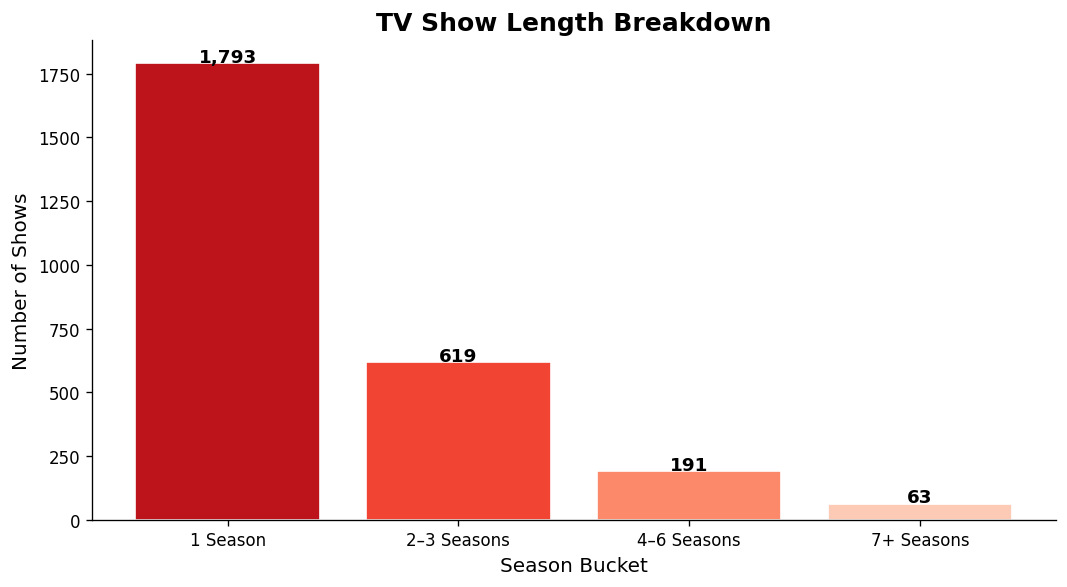

Saved: charts/tv_season_buckets.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [32]:
from google.colab import files
bucket_order = ['1 Season', '2–3 Seasons', '4–6 Seasons', '7+ Seasons']
buckets = df['season_bucket'].value_counts().reindex(bucket_order).fillna(0)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(buckets.index, buckets.values,
              color=sns.color_palette('Reds_r', 4), edgecolor='white')
ax.set_title('TV Show Length Breakdown', fontsize=15, fontweight='bold')
ax.set_xlabel('Season Bucket'); ax.set_ylabel('Number of Shows')
for bar, val in zip(bars, buckets.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            f'{int(val):,}', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/tv_season_buckets.png', bbox_inches='tight')
plt.show()
print('Saved: charts/tv_season_buckets.png')
files.download('charts/tv_season_buckets.png')

**Insight:** Over **60% of Netflix TV Shows have just 1 season** — confirming a clear platform preference for **limited series and miniseries**. Shows running 7+ seasons are rare, reserved for flagship originals.

### 7.9 Correlation-Style Heatmap — Type × Rating

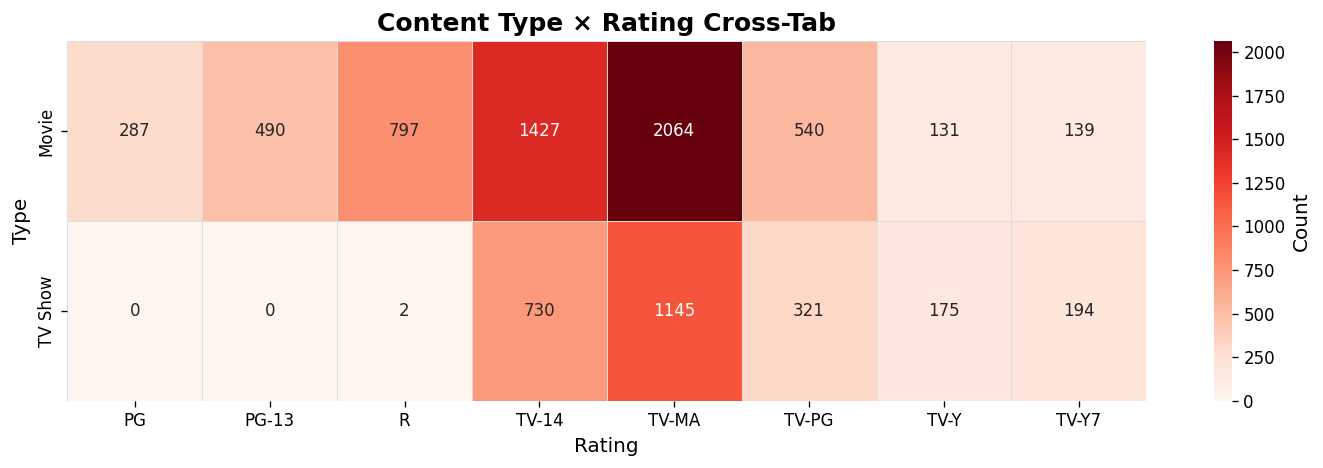

Saved: charts/type_rating_heatmap.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [33]:
from google.colab import files
top_ratings = df['rating'].value_counts().head(8).index
pivot_rating = (
    df[df['rating'].isin(top_ratings)]
    .groupby(['type', 'rating'])
    .size()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(pivot_rating, annot=True, fmt='d', cmap='Reds',
            linewidths=0.5, linecolor='#ddd', ax=ax,
            cbar_kws={'label': 'Count'})
ax.set_title('Content Type × Rating Cross-Tab', fontsize=15, fontweight='bold')
ax.set_xlabel('Rating'); ax.set_ylabel('Type')
plt.tight_layout()
plt.savefig('charts/type_rating_heatmap.png', bbox_inches='tight')
plt.show()
print('Saved: charts/type_rating_heatmap.png')
files.download('charts/type_rating_heatmap.png')

**Insight:** **TV-MA is by far the most common rating for both Movies and TV Shows**. TV Shows are slightly more skewed towards TV-MA compared to Movies, where R-rated content also appears substantially.

---
## 8. Insights & Conclusion <a id='8'></a>

### Key Findings

| # | Finding | Implication |
|---|---------|-------------|
| 1 | **Movies outnumber TV Shows 2:1** | Netflix built on film; TV originals are the growth lever |
| 2 | **TV-MA dominates ratings** | Platform is positioned for mature adults, not families |
| 3 | **Content additions peaked 2019** | Reflects pre-COVID content splurge |
| 4 | **USA & India are top producers** | Two-market dependency; Bollywood is a core pillar |
| 5 | **International Movies is the #1 genre tag** | Netflix's global ambition is reflected in its catalog |
| 6 | **July & December are peak months** | Content drops are timed around holidays |
| 7 | **60%+ TV Shows have 1 season** | Miniseries strategy reduces long-term production risk |
| 8 | **Movie runtimes cluster at 80–120 min** | Optimised for single-session streaming comfort |
| 9 | **Catalog is heavily recent (0–10 yr content)** | Netflix is a trends platform, not an archive |
| 10 | **Korea's niche is almost all K-Dramas** | Concentrated but high global-impact content vertical |

---

### Final Conclusion

Netflix's catalog reflects a carefully engineered content strategy:

- **Volume over depth** — massive movie libraries with short TV runs keep variety high and production costs manageable.
- **Global with local flavor** — country-specific genres (Bollywood, K-Drama, Anime) anchor regional subscriber bases while `International` tags cross-sell them globally.
- **Adult-first** — the TV-MA dominance tells us Netflix competes on prestige drama, not family entertainment.
- **Time-aware releases** — the seasonal spikes in July and December show a clear marketing calendar behind every title drop.

For any aspiring data analyst, this dataset is a masterclass in why **data cleaning + feature engineering** matter as much as the charts themselves — the `duration`, `listed_in`, and `date_added` columns each required non-trivial transformation before any useful insight could be extracted.

---

### Saved Charts Summary

```
charts/
├── movies_vs_tv.png
├── ratings_distribution.png
├── content_added_per_year.png
├── top_countries.png
├── top_genres.png
├── monthly_addition_trend.png
├── heatmap_year_month.png
├── duration_analysis.png
├── stacked_year_type.png
├── content_age_decade.png
├── treemap_genre.png
├── sunburst_country_genre.png
├── timeseries_additions.png
├── tv_season_buckets.png
└── type_rating_heatmap.png
```

In [34]:
print('=' * 55)
print(' FINAL DATASET SUMMARY')
print('=' * 55)
print(f'  Total titles analysed  : {len(df):,}')
print(f'  Movies                 : {(df["type"]=="Movie").sum():,}')
print(f'  TV Shows               : {(df["type"]=="TV Show").sum():,}')
print(f'  Countries represented  : {df["primary_country"].nunique()}')
print(f'  Unique genres (primary): {df["primary_genre"].nunique()}')
print(f'  Date range             : {df["date_added"].min().date()} → {df["date_added"].max().date()}')
print(f'  Charts saved to        : ./charts/ ({len(os.listdir("charts"))} files)')
print('=' * 55)
print('Analysis complete!')

 FINAL DATASET SUMMARY
  Total titles analysed  : 8,797
  Movies                 : 6,131
  TV Shows               : 2,666
  Countries represented  : 87
  Unique genres (primary): 36
  Date range             : 2008-01-01 → 2021-09-25
  Charts saved to        : ./charts/ (15 files)
Analysis complete!
